In [69]:
import pandas as pd
from pathlib import Path

test = "0"
parameter = "translation_x"
scene = "empty"
camera = "camera1"
csv_path = Path(f"Output/{scene}/{parameter}/{test}/{camera}_{parameter}_sweep.csv")

if not csv_path.exists():
    raise FileNotFoundError(f"CSV file not found: {csv_path}")

df = pd.read_csv(csv_path)

required_columns = {f"{parameter}", "loss", "analytic_grad", "fd_grad"}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

df.head()

,iter,translation_x,loss,analytic_grad,fd_grad,fd_kind,fd_epsilon
0,0,-0.250,0.001463,-0.010864,-0.010971,0,0.005
1,1,-0.225,0.001199,-0.010003,-0.010118,0,0.005
2,2,-0.200,0.000958,-0.009082,-0.009190,0,0.005
3,3,-0.175,0.000741,-0.008096,-0.008195,0,0.005
4,4,-0.150,0.000549,-0.007054,-0.007140,0,0.005


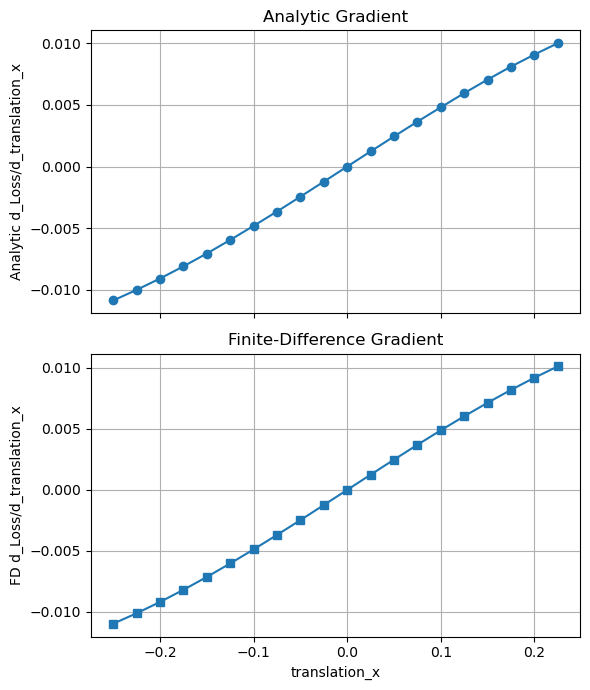

PosixPath('Output/empty/translation_x/0/camera1_translation_x_sweep_grad_subplots.png')

In [70]:
import matplotlib.pyplot as plt

NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 7), sharex=True)

# --- Top: Analytic ---
axes[0].plot(df[f"{parameter}"], df["analytic_grad"], marker="o")
axes[0].set_ylabel(f"Analytic d_Loss/d_{parameter}")
axes[0].set_title("Analytic Gradient")
axes[0].grid(True)

# --- Bottom: Finite Difference ---
axes[1].plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s")
axes[1].set_xlabel(f"{parameter}")
axes[1].set_ylabel(f"FD d_Loss/d_{parameter}")
axes[1].set_title("Finite-Difference Gradient")
axes[1].grid(True)

output_png = csv_path.with_name(csv_path.stem + "_grad_subplots.png")
plt.tight_layout()
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

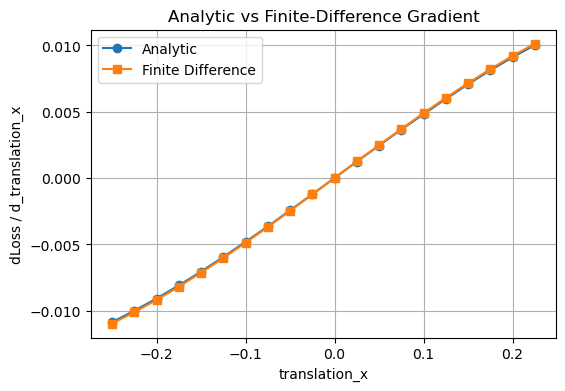

PosixPath('Output/empty/translation_x/0/camera1_translation_x_sweep_grad_compare.png')

In [71]:
NUMERICAL_COLUMN = "fd_grad"

required_columns = {f"{parameter}", "analytic_grad", NUMERICAL_COLUMN}
if not required_columns.issubset(df.columns):
    raise RuntimeError(f"CSV must contain columns: {required_columns}")

plt.figure(figsize=(6, 4))

plt.plot(df[f"{parameter}"], df["analytic_grad"], marker="o", label="Analytic")
plt.plot(df[f"{parameter}"], df[NUMERICAL_COLUMN], marker="s", label="Finite Difference")

plt.xlabel(f"{parameter}")
plt.ylabel(f"dLoss / d_{parameter}")
plt.title("Analytic vs Finite-Difference Gradient")
plt.grid(True)
plt.legend()

output_png = csv_path.with_name(csv_path.stem + "_grad_compare.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

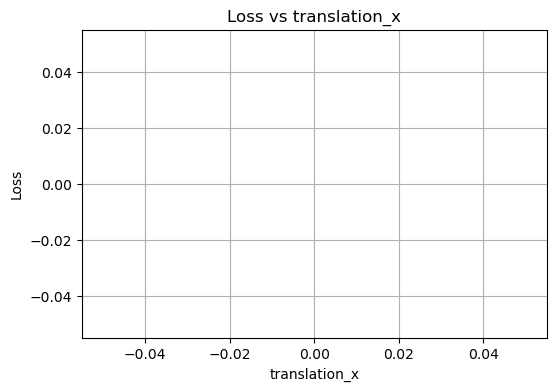

PosixPath('Output/empty/translation_x/0/camera1_translation_x_sweep_loss.png')

In [65]:
plt.figure(figsize=(6, 4))
plt.plot(df[f"{parameter}"], df["loss"], marker="o")
plt.xlabel(f"{parameter}")
plt.ylabel("Loss")
plt.title(f"Loss vs {parameter}")
plt.grid(True)

output_png = csv_path.with_name(csv_path.stem + "_loss.png")
plt.savefig(output_png, dpi=200, bbox_inches="tight")
plt.show()

output_png

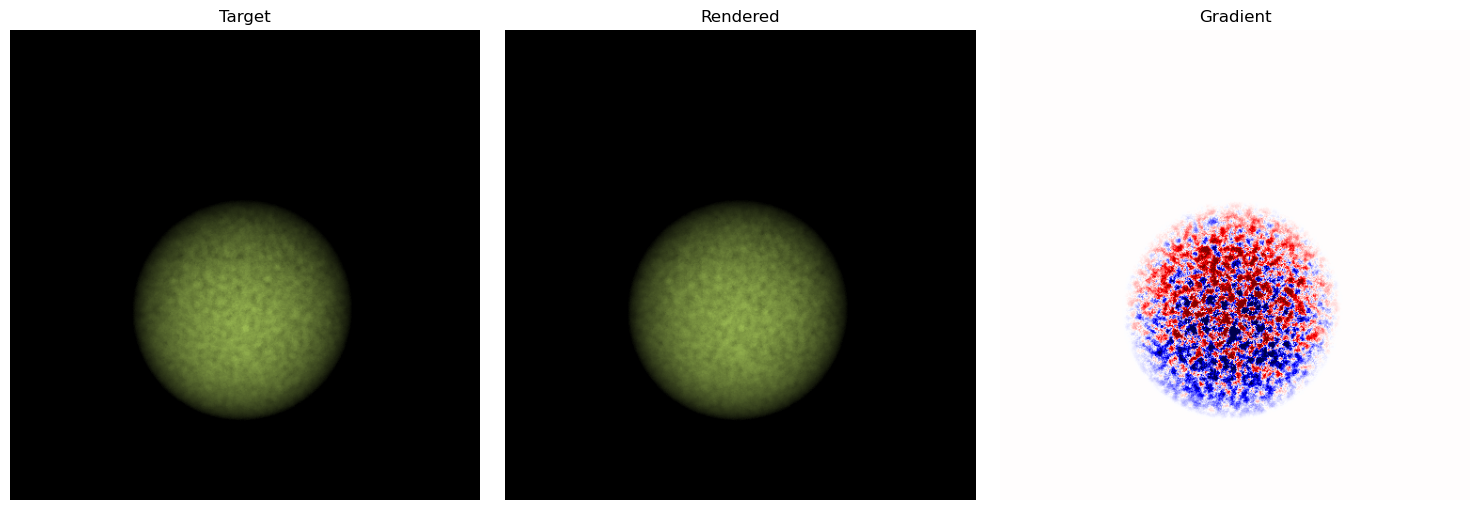

In [44]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Paths
iteration = 3
target_image = Path(f"Output/{scene}/{parameter}/{camera}_target.png")
rendered_test = Path(f"Output/{scene}/{parameter}/{test}/rendered/{iteration}_{camera}.png")
grad_image = Path(f"Output/{scene}/{parameter}/{test}/grad/{iteration}_{camera}.png")



# Load images
img_target = Image.open(target_image)
img_rendered = Image.open(rendered_test)
img_grad = Image.open(grad_image)

# Plot side by side (3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_target)
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(img_rendered)
axes[1].set_title("Rendered")
axes[1].axis("off")

axes[2].imshow(img_grad)
axes[2].set_title("Gradient")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [45]:
print(df["analytic_grad"])
print(df[NUMERICAL_COLUMN])


0    -1.333552e-03
1    -7.568172e-04
2    -2.895286e-04
3    -4.886113e-05
4     3.943670e-05
5     4.340799e-12
6     1.428388e-05
7     1.417791e-04
8     3.146032e-04
9     5.530245e-04
10    6.567860e-04
Name: analytic_grad, dtype: float64
0    -5.325048e-04
1    -3.180303e-04
2    -1.333983e-04
3    -3.664277e-05
4    -2.126231e-05
5     4.543397e-08
6     1.204104e-04
7     3.655259e-04
8     6.600945e-04
9     9.055919e-04
10    9.970478e-04
Name: fd_grad, dtype: float64
